In [1]:
import gifba
from scipy.integrate import solve_ivp
import numpy as np
import cobra as cb
import pandas as pd
from IPython.display import clear_output
import copy

In [2]:
def rename_community_biomass(models, old_biomass_id="EX_Bio(e)"):
    """
    Renames the biomass exchange reactions and their associated metabolites 
    to track individual species separately.
    """
    # Deepcopy ensures we don't accidentally modify the original template models
    updated_models = copy.deepcopy(models)
    
    for idx, model in enumerate(updated_models):
        suffix = f"_{idx + 1}"  # e.g., _1, _2
        
        if old_biomass_id in model.reactions:
            # 1. Isolate the biomass reaction
            biomass_rxn = model.reactions.get_by_id(old_biomass_id)
            
            # 2. Rename the associated biomass metabolite(s) FIRST
            # We cast to list() to avoid modifying a dictionary while iterating over it
            for metabolite in list(biomass_rxn.metabolites):
                metabolite.id = f"{metabolite.id}{suffix}"
                # Optional: update the metabolite name for clarity
                metabolite.name = f"{metabolite.name} (Species {idx + 1})"
            
            # 3. Rename the reaction itself
            biomass_rxn.id = f"{old_biomass_id}{suffix}"
            biomass_rxn.name = f"{biomass_rxn.name} (Species {idx + 1})"
            
    return updated_models

In [11]:

models, media = gifba.utils.load_simple_models("2_1_competition")
renamed_models = rename_community_biomass(models, old_biomass_id="EX_Bio(e)")


community = gifba.gifbaObject(renamed_models, media, [0.2, 0.8])
_, _ = community.run_gifba(iters=1, method="pfba", v=False)
clear_output()

# equal rel_abund
rel_abund = community.rel_abund.copy()

# media from gifba
substrate_0 = community.env_fluxes.loc[0, :].to_dict()
substrate_0

# kinetic params
V_MAX_ALL = 100  # (mmol/(gi*hr)) Maximum uptake rate for all substrates
K_M_ALL = 0.1  # (mmol) Michaelis-Menten constant for all substrates
vmax_vals = pd.DataFrame(np.full((len(models), len(substrate_0.keys())), V_MAX_ALL),
                              columns=list(substrate_0.keys()),
                              index=[str(mdl_idx) for mdl_idx in range(len(models))])
km_vals = pd.DataFrame(np.full((len(models), len(substrate_0.keys())), K_M_ALL),
                              columns=list(substrate_0.keys()),
                              index=[str(mdl_idx) for mdl_idx in range(len(models))])


    


In [12]:
def dsdt(t, S, models, vmax, km, media_keys):
    # Initialize the rate of change for each metabolite to 0
    dsdt_rates = np.zeros(len(S))
    
    # Create a mapping for quick lookup: {metabolite_id: current_concentration}
    conc_map = dict(zip(media_keys, S))

    # randomly select one model to run FBA for each time step
    # selected_model_idx = np.random.choice(len(models))
    
    for mdl_idx, model in enumerate(models):
        # 1. Update lower bounds based on Michaelis-Menten kinetics
        for ex_id in media_keys:
            if ex_id in model.reactions and "bio" not in ex_id:
                v_max = vmax.loc[str(mdl_idx), ex_id]
                k_m = km.loc[str(mdl_idx), ex_id]
                c = conc_map[ex_id]
                
                if c < 1e-6:
                    c = 0.0  # Avoid very small concentrations causing numerical errors

                # Michaelis-Menten uptake limit 
                uptake_limit = (v_max * c) / (k_m + c) # (mmol/(gi*hr))
                
                # In COBRA, uptake is negative, so lower_bound is -uptake_limit
                model.reactions.get_by_id(ex_id).lower_bound = -uptake_limit

        # 2. Run FBA
        solution = model.optimize()

        # 3. Add fluxes to the net rate of change (weighted by clamped relative abundance)
        if solution.status == 'optimal':
            for i, ex_id in enumerate(media_keys):
                # Convert flux to per second (assuming original is per hour)
                flux_per_second = solution.fluxes.get(ex_id, 0) / 3600 
                
                # We add the RATE of change to our array. solve_ivp handles the integration over time.
                dsdt_rates[i] += flux_per_second * rel_abund[mdl_idx]

    # 4. Add media fluxes to rate of change
    for i, ex_id in enumerate(media_keys):
        media_flux = community.env_fluxes.loc[0, ex_id] / 3600  # Convert to per second
        dsdt_rates[i] += media_flux 

    return dsdt_rates

# Preparing cleaner inputs for solve_ivp
m_keys = list(substrate_0.keys()) 
m_vals = np.array([substrate_0[k] for k in m_keys]) 
#y0 = m_vals.copy()
y0 = np.zeros(len(m_vals))  # Start with zero concentrations for all metabolites

sol = solve_ivp(
    dsdt,
    t_span=(0, 500),
    y0=y0,
    args=(copy.deepcopy(renamed_models), vmax_vals, km_vals, m_keys),
    method='BDF' # BDF is excellent for stiff biological ODEs
)

Read LP format model from file /var/folders/yp/dx3zqgf139ndbl_1xyc8_nf00000gq/T/tmpa5kzvqr7.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros
Read LP format model from file /var/folders/yp/dx3zqgf139ndbl_1xyc8_nf00000gq/T/tmpy8tr3c_d.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros


/var/folders/yp/dx3zqgf139ndbl_1xyc8_nf00000gq/T/ipykernel_87868/2348956023.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dsdt_rates[i] += flux_per_second * rel_abund[mdl_idx]


In [13]:
print(m_keys)

['EX_A(e)', 'EX_Bio(e)_2', 'EX_Bio(e)_1']


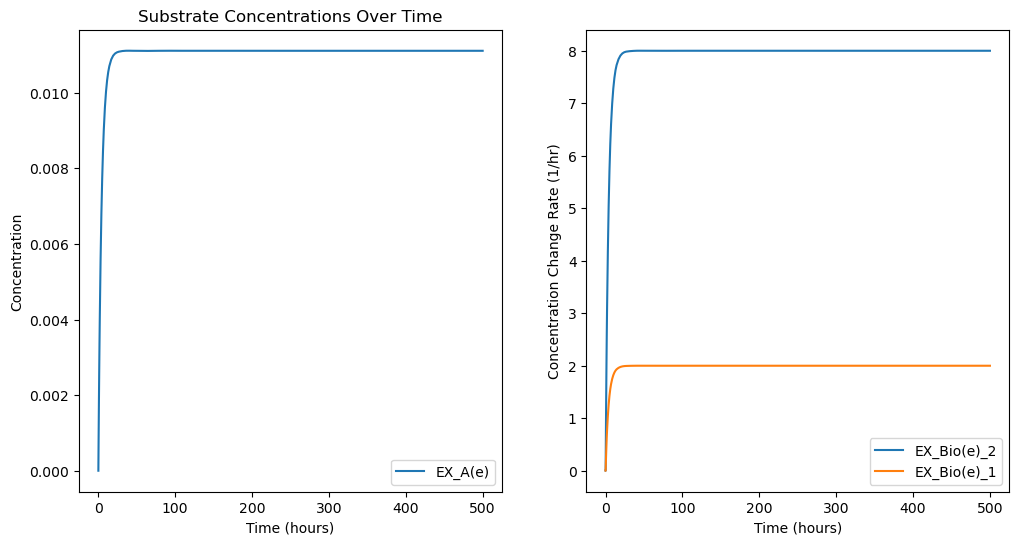

In [14]:
# plot each metabolite's concentration over time
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
for i, metabolite in enumerate(m_keys):
    if "Bio" in metabolite:
        # plot slope of biomass concentrations over time
        slope = np.gradient(sol.y[i], sol.t)
        ax[1].plot(sol.t, slope*3600, label=metabolite)
        ax[1].set_xlabel('Time (hours)')
        ax[1].set_ylabel('Concentration Change Rate (1/hr)')
        ax[1].legend()

        #ax[1].plot(sol.t, sol.y[i], label=metabolite)
        #ax[1].set_xlabel('Time (hours)')
        #ax[1].set_ylabel('Concentration')
        #ax[1].set_title('Biomass Concentrations Over Time')
        #ax[1].legend()
    else:
        ax[0].plot(sol.t, sol.y[i], label=metabolite)
        ax[0].set_xlabel('Time (hours)')
        ax[0].set_ylabel('Concentration')
        ax[0].set_title('Substrate Concentrations Over Time')
        ax[0].legend()

Read LP format model from file /var/folders/yp/dx3zqgf139ndbl_1xyc8_nf00000gq/T/tmpdlmu28fo.lp
Reading time = 0.00 seconds
: 8 rows, 20 columns, 36 nonzeros
Read LP format model from file /var/folders/yp/dx3zqgf139ndbl_1xyc8_nf00000gq/T/tmpxevfzy9h.lp
Reading time = 0.00 seconds
: 8 rows, 20 columns, 36 nonzeros


/var/folders/yp/dx3zqgf139ndbl_1xyc8_nf00000gq/T/ipykernel_87868/2348956023.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dsdt_rates[i] += flux_per_second * rel_abund[mdl_idx]


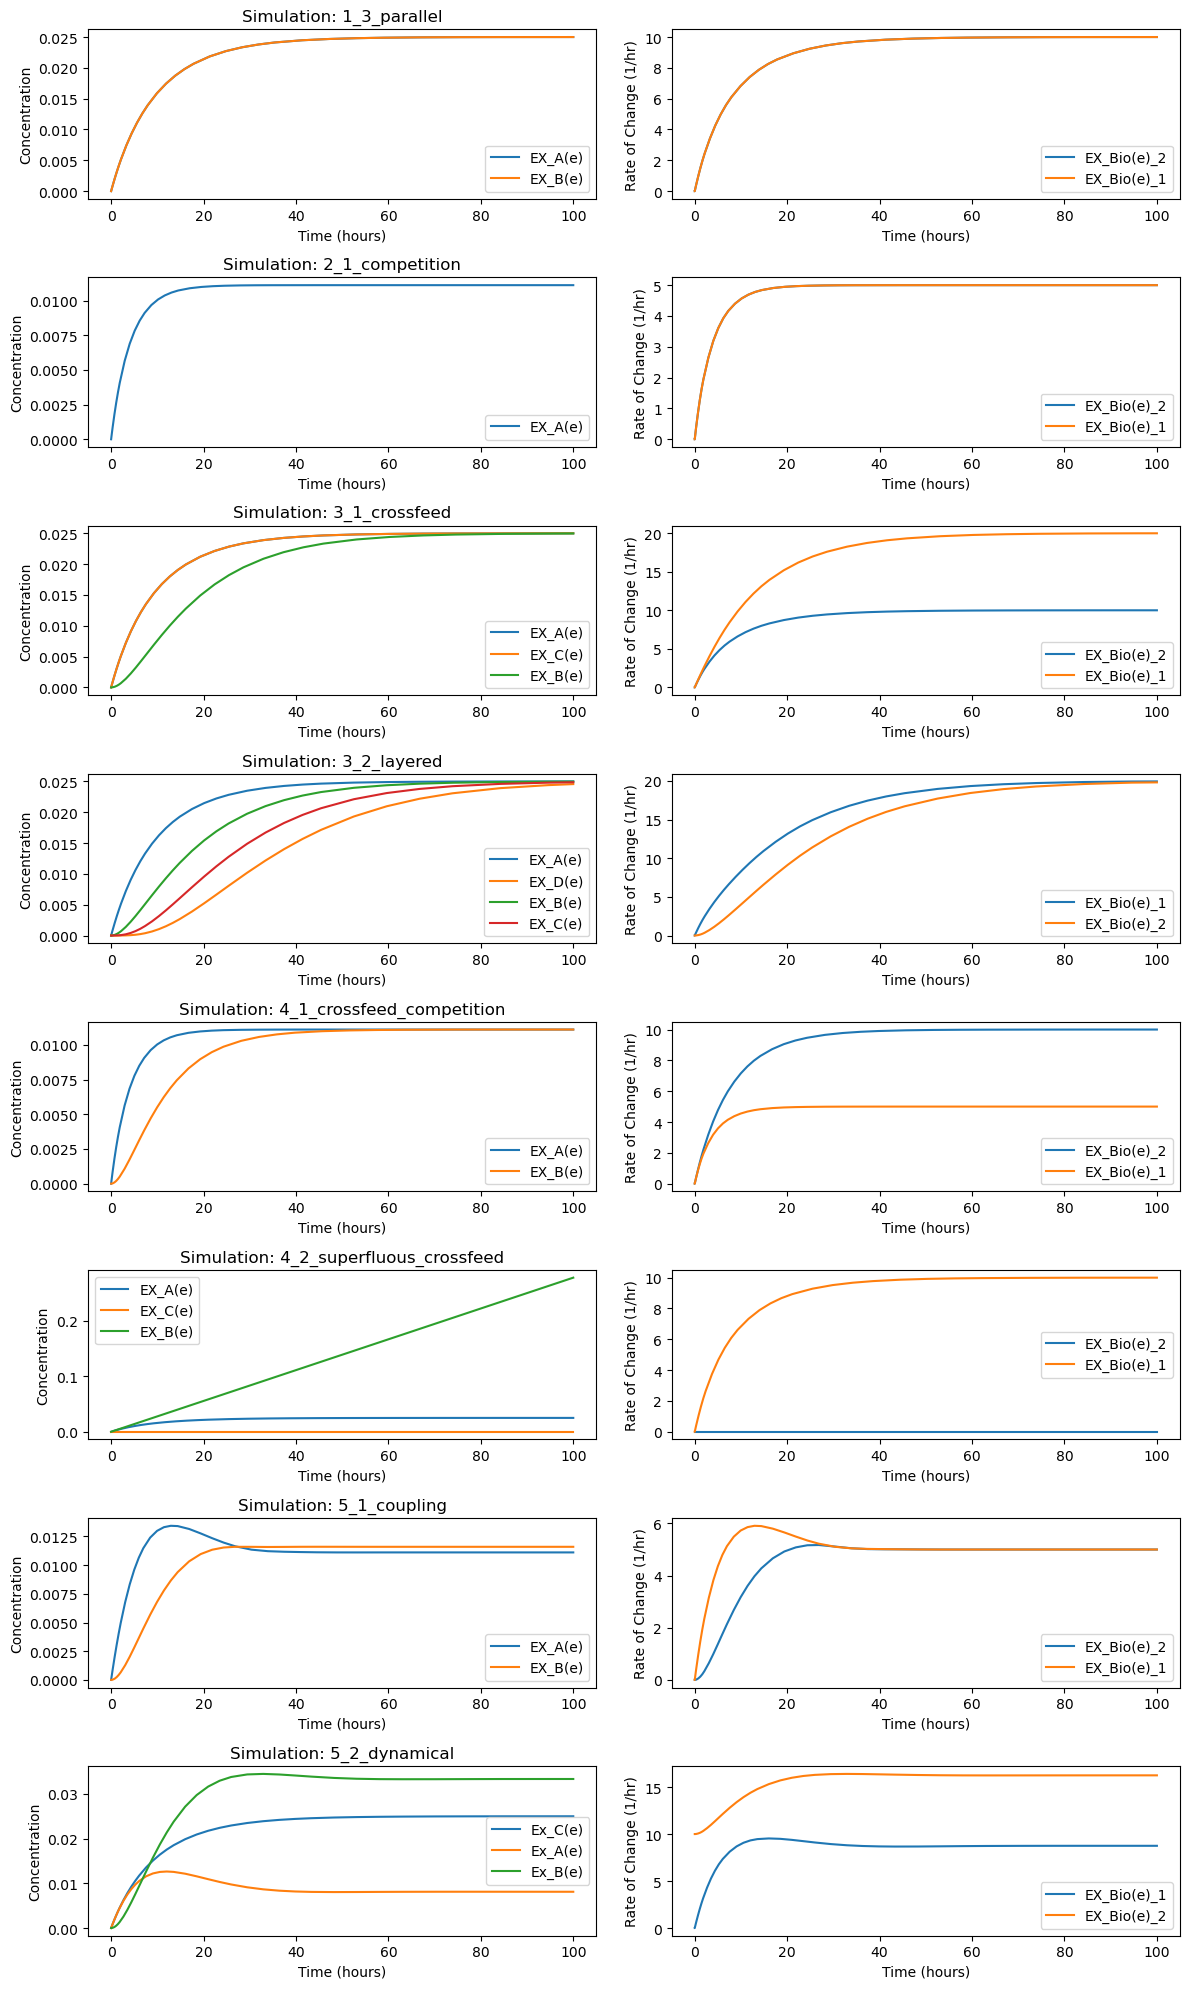

In [24]:
# run clamped dfba for all simulations
sims = ["1_3_parallel",
        "2_1_competition",
        "3_1_crossfeed",
        "3_2_layered",
        "4_1_crossfeed_competition",
        "4_2_superfluous_crossfeed",
        "5_1_coupling",
        "5_2_dynamical"]
fig, ax = plt.subplots(nrows=len(sims), ncols=2, figsize=(12, 20), clear=True)
ax = ax.flatten()

for sim_idx, sim in enumerate(sims):
    print(f"Running simulation {sim_idx + 1}: {sim}")
    models, media = gifba.utils.load_simple_models(sim)
    renamed_models = rename_community_biomass(models, old_biomass_id="EX_Bio(e)")


    community = gifba.gifbaObject(renamed_models, media, [0.5, 0.5])
    _, _ = community.run_gifba(iters=1, method="pfba", v=False)
    clear_output()

    # equal rel_abund
    rel_abund = community.rel_abund.copy()


    # def params
    diff_coef = 0.1  # Diffusion coefficient

    # media from gifba
    substrate_0 = community.env_fluxes.loc[0, :].to_dict()
    substrate_0

    # kinetic params
    V_MAX_ALL = 100  # Maximum uptake rate for all substrates
    K_M_ALL = 0.1  # Michaelis-Menten constant for all substrates
    vmax_vals = pd.DataFrame(np.full((len(models), len(substrate_0.keys())), V_MAX_ALL),
                                columns=list(substrate_0.keys()),
                                index=[str(mdl_idx) for mdl_idx in range(len(models))])
    km_vals = pd.DataFrame(np.full((len(models), len(substrate_0.keys())), K_M_ALL),
                                columns=list(substrate_0.keys()),
                                index=[str(mdl_idx) for mdl_idx in range(len(models))])


        
    # Preparing cleaner inputs for solve_ivp
    m_keys = list(substrate_0.keys()) 
    m_vals = np.array([substrate_0[k] for k in m_keys]) 
    #y0 = m_vals.copy()
    y0 = np.zeros(len(m_vals))  # Start with zero concentrations for all metabolites

    sol = solve_ivp(
        dsdt,
        t_span=(0, 100),
        y0=y0,
        args=(copy.deepcopy(renamed_models), vmax_vals, km_vals, m_keys),
        method='BDF' # BDF is excellent for stiff biological ODEs
    )


    for i, metabolite in enumerate(m_keys):
        if "Bio" in metabolite:
            slope = np.gradient(sol.y[i], sol.t)
            ax[2*sim_idx+1].plot(sol.t, slope*3600, label=metabolite)
            ax[2*sim_idx+1].set_xlabel('Time (hours)')
            ax[2*sim_idx+1].set_ylabel('Rate of Change (1/hr)')
            ax[2*sim_idx+1].legend()
        else:
            ax[2*sim_idx].plot(sol.t, sol.y[i], label=metabolite)
            ax[2*sim_idx].set_xlabel('Time (hours)')
            ax[2*sim_idx].set_ylabel('Concentration')
            ax[2*sim_idx].set_title('Simulation: ' + sim)
            ax[2*sim_idx].legend()
plt.tight_layout()

In [29]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-04 ...  8.447e+01  1.000e+02]
        y: [[ 0.000e+00  2.778e-07 ...  2.499e-02  2.500e-02]
            [ 0.000e+00  2.778e-07 ...  8.115e-03  8.110e-03]
            ...
            [ 0.000e+00  0.000e+00 ...  3.333e-02  3.334e-02]
            [ 0.000e+00  2.778e-07 ...  3.658e-01  4.359e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 91
     njev: 2
      nlu: 13